## Introduction to Pandas

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


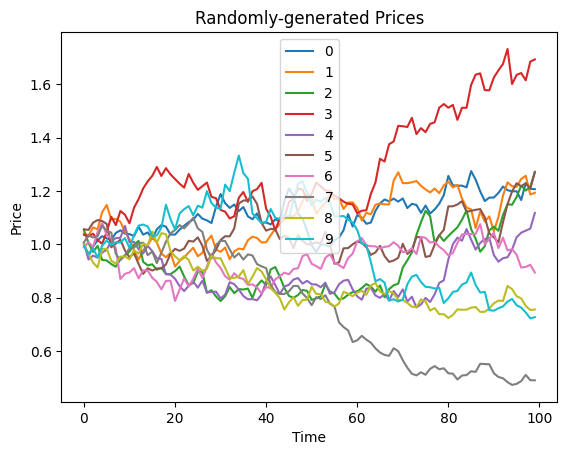

In [62]:
returns = pd.DataFrame(np.random.normal(1.0, 0.03, (100, 10)))
prices = returns.cumprod()
prices.plot()
plt.title('Randomly-generated Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend(loc=0);


#### Series

In [63]:
s = pd.Series([1, 2, np.nan, 4, 5])
print(s)


0    1.0
1    2.0
2    NaN
3    4.0
4    5.0
dtype: float64


In [64]:
print(s.name)


None


In [65]:
s.name = "Toy Series"
print(s.name)


Toy Series


In [66]:
print(s.index)


RangeIndex(start=0, stop=5, step=1)


In [67]:
new_index = pd.date_range("2016-01-01", periods=len(s), freq="D")
print(new_index)


DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05'],
              dtype='datetime64[us]', freq='D')


In [68]:
s.index = new_index
print(s.index)


DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05'],
              dtype='datetime64[us]', freq='D')


In [69]:
print("First element of the series:", s.iloc[0])
print("Last element of the series:", s.iloc[len(s) - 1])


First element of the series: 1.0
Last element of the series: 5.0


In [70]:
s.iloc[:2]


2016-01-01    1.0
2016-01-02    2.0
Freq: D, Name: Toy Series, dtype: float64

In [71]:
start = 0
end = len(s) - 1
step = 1

s.iloc[start:end:step]


2016-01-01    1.0
2016-01-02    2.0
2016-01-03    NaN
2016-01-04    4.0
Freq: D, Name: Toy Series, dtype: float64

In [72]:
s.iloc[::-1]


2016-01-05    5.0
2016-01-04    4.0
2016-01-03    NaN
2016-01-02    2.0
2016-01-01    1.0
Freq: -1D, Name: Toy Series, dtype: float64

In [73]:
s.iloc[-2:-4:-1]


2016-01-04    4.0
2016-01-03    NaN
Freq: -1D, Name: Toy Series, dtype: float64

In [74]:
s.loc['2016-01-1']


np.float64(1.0)

In [75]:
s.loc['2016-01-02':'2016-01-04']


2016-01-02    2.0
2016-01-03    NaN
2016-01-04    4.0
Freq: D, Name: Toy Series, dtype: float64

In [76]:
print(s < 3)


2016-01-01     True
2016-01-02     True
2016-01-03    False
2016-01-04    False
2016-01-05    False
Freq: D, Name: Toy Series, dtype: bool


In [77]:
print(s.loc[s < 3])


2016-01-01    1.0
2016-01-02    2.0
Freq: D, Name: Toy Series, dtype: float64


In [78]:
print(s.loc[(s < 3) & (s > 1)])


2016-01-02    2.0
Freq: D, Name: Toy Series, dtype: float64


In [79]:
symbol = "CMG"
start = "2012-01-01"
end = "2016-01-01"
prices = yf.download(symbol, start=start, end=end)["Close"]


[*********************100%***********************]  1 of 1 completed


In [80]:
print("\n", type(prices))
prices.head(5)



 <class 'pandas.DataFrame'>


Ticker,CMG
Date,
2012-01-03,6.8254
2012-01-04,6.9750
2012-01-05,7.0096
2012-01-06,6.9790
2012-01-09,6.7948


In [81]:
# Force prices to be a 1D Series dynamically by taking the first column
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

print("Old name:", prices.name)
prices.name = symbol
print("New name:", prices.name)


Old name: CMG
New name: CMG


In [82]:
print(prices.index)


DatetimeIndex(['2012-01-03', '2012-01-04', '2012-01-05', '2012-01-06',
               '2012-01-09', '2012-01-10', '2012-01-11', '2012-01-12',
               '2012-01-13', '2012-01-17',
               ...
               '2015-12-17', '2015-12-18', '2015-12-21', '2015-12-22',
               '2015-12-23', '2015-12-24', '2015-12-28', '2015-12-29',
               '2015-12-30', '2015-12-31'],
              dtype='datetime64[s]', name='Date', length=1006, freq=None)


In [83]:
monthly_prices = prices.resample('ME').last()
monthly_prices.head(10)


Date
2012-01-31    7.3458
2012-02-29    7.8044
2012-03-31    8.3600
2012-04-30    8.2830
2012-05-31    8.2614
2012-06-30    7.5990
2012-07-31    5.8466
2012-08-31    5.7728
2012-09-30    6.3508
2012-10-31    5.0906
Freq: ME, Name: CMG, dtype: float64

In [84]:
monthly_prices_med = prices.resample("ME").median()
monthly_prices_med.head(10)


Date
2012-01-31    7.1101
2012-02-29    7.5639
2012-03-31    8.1799
2012-04-30    8.4167
2012-05-31    8.1048
2012-06-30    8.0490
2012-07-31    7.6094
2012-08-31    5.9078
2012-09-30    6.6562
2012-10-31    5.7312
Freq: ME, Name: CMG, dtype: float64

In [85]:
def custom_resampler(array_like):
    # Safely returns the first positional value of the period using .iloc
    return array_like.iloc[0]

# Pass your custom function inside .apply()
first_of_month_prices = prices.resample("ME").apply(custom_resampler)
first_of_month_prices.head(10)


Date
2012-01-31    6.8254
2012-02-29    7.4082
2012-03-31    7.8820
2012-04-30    8.3680
2012-05-31    8.3978
2012-06-30    7.9428
2012-07-31    7.6692
2012-08-31    5.6134
2012-09-30    5.7198
2012-10-31    6.3226
Freq: ME, Name: CMG, dtype: float64

In [86]:
eastern_prices = prices.tz_localize("US/Eastern")
eastern_prices.head(10)


Date
2012-01-03 00:00:00-05:00    6.8254
2012-01-04 00:00:00-05:00    6.9750
2012-01-05 00:00:00-05:00    7.0096
2012-01-06 00:00:00-05:00    6.9790
2012-01-09 00:00:00-05:00    6.7948
2012-01-10 00:00:00-05:00    6.8224
2012-01-11 00:00:00-05:00    6.9520
2012-01-12 00:00:00-05:00    6.9524
2012-01-13 00:00:00-05:00    7.0924
2012-01-17 00:00:00-05:00    7.0676
Name: CMG, dtype: float64

In [87]:
calendar_dates = pd.date_range(start=start, end=end, freq="D")
print(calendar_dates)


DatetimeIndex(['2012-01-01', '2012-01-02', '2012-01-03', '2012-01-04',
               '2012-01-05', '2012-01-06', '2012-01-07', '2012-01-08',
               '2012-01-09', '2012-01-10',
               ...
               '2015-12-23', '2015-12-24', '2015-12-25', '2015-12-26',
               '2015-12-27', '2015-12-28', '2015-12-29', '2015-12-30',
               '2015-12-31', '2016-01-01'],
              dtype='datetime64[us]', length=1462, freq='D')


In [88]:
calendar_prices = prices.reindex(calendar_dates, method="ffill")
calendar_prices.head(15)


2012-01-01       NaN
2012-01-02       NaN
2012-01-03    6.8254
2012-01-04    6.9750
2012-01-05    7.0096
2012-01-06    6.9790
2012-01-07    6.9790
2012-01-08    6.9790
2012-01-09    6.7948
2012-01-10    6.8224
2012-01-11    6.9520
2012-01-12    6.9524
2012-01-13    7.0924
2012-01-14    7.0924
2012-01-15    7.0924
Freq: D, Name: CMG, dtype: float64